### Import packages

In [1]:
#Import general libs you'll need
import os
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np

# Import functions from main
from main import ATL_AGG_CONFIG

# Import functions from the utils
from utils import readers, analysis, processing
from utils import plotter
from utils.create_las_swath import create_als_swath, transform_als_swath
from utils.datum_transforms import convert_3d_nad83_to_wgs84
from utils.datum_transforms import get_geoid_height



### Identify files



In [2]:
atl03_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/austin'
atl03_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/footprint_exp/austin_data'
atl03_name = 'ATL03_20250616013703_00052802_007_01.h5'
atl03_name = 'ATL03_20181215070448_11860106_007_01.h5'
atl03_file = os.path.join(atl03_dir, atl03_name)

# Define ATL08 File /home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/austin
atl08_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/austin'
atl08_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/footprint_exp/austin_data'
atl08_name = 'ATL08_20250616013703_00052802_007_01.h5'
atl08_name = 'ATL08_20181215070448_11860106_007_01.h5'
atl08_file = os.path.join(atl08_dir, atl08_name)

# Define the ground track of interest
gt = 'gt2l'

# Identify ATX AOI
extent_file = '/home/ejg2736/dev/icesat2_topobathy/data/austin_laz_bigtex.gpkg'

# ALS Geoid File
als_geoid_file = '/home/ejg2736/dev/geoid/agisoft/us_noaa_g2018u0.tif'

### Get photon rate dataframe


In [3]:
# Get photon rate DF
df_ph = readers.read_photon_dataframe(atl03_file, gt, atl08_file)


In [4]:
# Filter df_ph
extent_gdf = gpd.read_file(extent_file)
df_ph = processing.filter_df_by_extent(df_ph, extent_gdf.total_bounds)


### Plot output 

Check to make sure it plots correctly

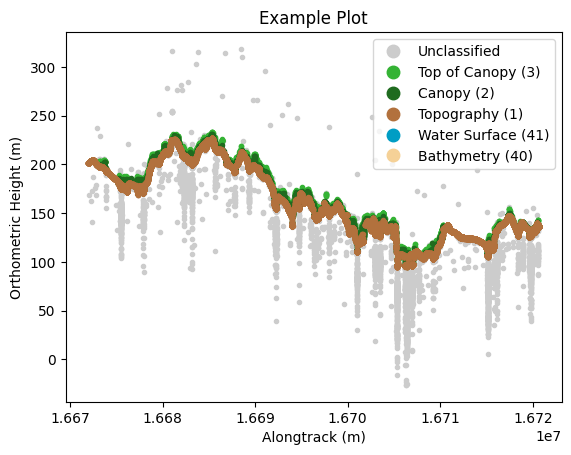

In [5]:
import matplotlib.pyplot as plt
plotter.plot_alongtrack(df_ph.alongtrack, df_ph.h_ph, df_ph.atl08_class,'Example Plot')

### Process ALS Swath

Load the ALS Swath and preprocess it 

In [6]:
os.path.basename(atl03_name).split('.h5')[0]

'ATL03_20181215070448_11860106_007_01'

In [7]:
# Load swath if available
als_outdir = '/home/ejg2736/dev/icesat2_topobathy/als_swaths'
file_out_name = f"{os.path.basename(atl03_name).split('.h5')[0]}_{gt}"
als_outfile = os.path.join(als_outdir, f'als_{file_out_name}.pqt')                
if os.path.exists(als_outfile):
    als_swath = pd.read_parquet(als_outfile)
else:
    als_swath = create_als_swath(extent_gdf, df_ph)
    als_swath = transform_als_swath(als_swath, 
        'EPSG:32614', 
        source_geoid_file=als_geoid_file,
        target_geoid_file=None, 
        input_units='feet', 
        source_datum='nad83'
    )
    als_swath.to_parquet(als_outfile)

/home/ejg2736/miniconda3/envs/spyder_pr/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


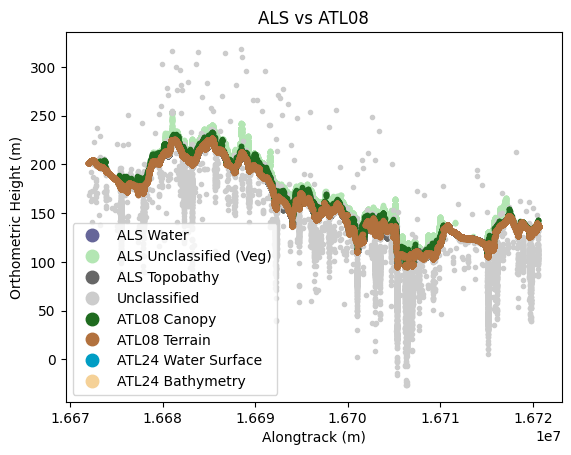

In [8]:
from utils.plotter import plot_alongtrack_atl_als3
plot_alongtrack_atl_als3(df_ph, als_swath,'ALS vs ATL08')

### Perform Geolocation Offset

Fine tune the fit between the ICESat-2 and the ALS swath.

In [32]:
%load_ext autoreload
%autoreload 2

# Call geolocation offset script
from utils.geolocation import create_interpolator


df_ph['crosstrack'] = 0


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
als_surface_interpolator = create_interpolator(als_swath, grid_resolution=1)

In [34]:
from utils.geolocation import calculate_mae_cost
from scipy.optimize import minimize, brute, fmin


search_grid = (slice(-10, 10, 0.5), slice(-10, 10, 0.5))

result = brute(
    calculate_mae_cost, 
    ranges=search_grid, 
    args=(df_ph.alongtrack[df_ph.atl08_class == 1], 
    df_ph.crosstrack[df_ph.atl08_class == 1], 
    df_ph.h_ph[df_ph.atl08_class == 1], als_surface_interpolator),
    finish=fmin, # This triggers the continuous fine-tuning step!
    full_output=True 
)

optimal_shift_at, optimal_shift_xt = result[0]
best_mae = result[1]

print(f"AT shift: {optimal_shift_at:.2f} m")
print(f"XT shift: {optimal_shift_xt:.2f} m")
print(f"Best MAE: {result[1]:.2f} m")

AT shift: 0.02 m
XT shift: 2.17 m
Best MAE: 0.72 m
